<a href="https://colab.research.google.com/github/kimgayeon430/data_analysis_lab/blob/main/travel_data_analysis_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **데이터 분석 및 활용 기말 프로젝트 - 2210723 김가연**
국내 여행로그 데이터 기반 사용자 맞춤형 데이트 코스 추천 서비스  
사용 데이터 : AI-hub 국내 여행로그 데이터 (수도권)  
AI-hub 사이트 : [링크 텍스트](https://aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&dataSetSn=71776)

## 0. 라이브러리 및 기본 설정

In [ ]:
import os
import glob
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
import zipfile
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display, HTML
from urllib.parse import quote

# 한글 폰트 설정
!apt-get -qq install fonts-nanum

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rc("font", family="NanumGothic")
mpl.rcParams["axes.unicode_minus"] = False

os.makedirs("/content/graphs", exist_ok=True)

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


## 1. 데이터 업로드 및 압축 해제

In [ ]:
from google.colab import files

print("TL_csv_zip.zip 파일을 업로드해주세요.")
uploaded_csv = files.upload()

TL_csv_zip.zip 파일을 업로드해주세요.


Saving TL_csv_zip.zip to TL_csv_zip.zip


In [ ]:
# 압축 풀기
zip_path = "/content/TL_csv_zip.zip"
extract_path = "/content/TL_csv"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['TL_csv']


## 2. 데이터 불러오기 및 구조 확인

In [8]:
csv_files = glob.glob("/content/TL_csv/TL_csv/*.csv")

for file in csv_files:
    try:
        df = pd.read_csv(file, encoding="utf-8-sig")
    except:
        df = pd.read_csv(file, encoding="cp949")

    print("\n==============================")
    print("파일명:", os.path.basename(file))
    print("행/열:", df.shape)
    print("컬럼:")
    print(list(df.columns))
    print(df.head(2))


파일명: tn_move_his_이동내역_E.csv
행/열: (21384, 8)
컬럼:
['TRAVEL_ID', 'TRIP_ID', 'START_VISIT_AREA_ID', 'END_VISIT_AREA_ID', 'START_DT_MIN', 'END_DT_MIN', 'MVMN_CD_1', 'MVMN_CD_2']
   TRAVEL_ID     TRIP_ID  START_VISIT_AREA_ID  END_VISIT_AREA_ID  \
0  e_e000004  2304300001         2.304300e+09                NaN   
1  e_e000004  2304300002                  NaN       2.304300e+09   

       START_DT_MIN        END_DT_MIN  MVMN_CD_1  MVMN_CD_2  
0  2023-04-30 13:30               NaN        NaN        NaN  
1               NaN  2023-04-30 14:00        1.0        NaN  

파일명: tn_companion_info_동반자정보_E.csv
행/열: (3537, 6)
컬럼:
['COMPANION_SEQ', 'TRAVEL_ID', 'REL_CD', 'COMPANION_GENDER', 'COMPANION_AGE_GRP', 'COMPANION_SITUATION']
   COMPANION_SEQ  TRAVEL_ID  REL_CD  COMPANION_GENDER  COMPANION_AGE_GRP  \
0              2  e_e000004       2                 1                  1   
1              1  e_e000004       1                 2                  4   

   COMPANION_SITUATION  
0                    

In [9]:
base_path = "/content"

def find_file(keyword):
    files = glob.glob(base_path + "/**/**/*.csv", recursive=True)
    matched = [f for f in files if keyword in os.path.basename(f)]
    if len(matched) == 0:
        raise FileNotFoundError(f"{keyword} 파일을 찾을 수 없습니다.")
    return matched[0]

def read_csv_auto(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except:
        return pd.read_csv(path, encoding="cp949")

visit = read_csv_auto(find_file("방문지정보"))
travel = read_csv_auto(find_file("여행_E"))
traveller = read_csv_auto(find_file("여행객"))
companion = read_csv_auto(find_file("동반자정보"))
consume = read_csv_auto(find_file("활동소비내역"))
codeb = read_csv_auto(find_file("코드B"))

print("각 데이터의 행/열 개수 파악")
print("방문지정보:", visit.shape)
print("여행:", travel.shape)
print("여행객:", traveller.shape)
print("동반자정보:", companion.shape)
print("활동소비내역:", consume.shape)
print("코드B:", codeb.shape)

각 데이터의 행/열 개수 파악
방문지정보: (21384, 23)
여행: (2560, 10)
여행객: (2560, 36)
동반자정보: (3537, 6)
활동소비내역: (11739, 18)
코드B: (238, 10)


## 3. 코드값 변환

In [10]:
# 방문지 유형 코드표
vis_code = codeb[codeb["cd_a"] == "VIS"][["cd_b", "cd_nm"]].copy()
vis_code["cd_b"] = pd.to_numeric(vis_code["cd_b"], errors="coerce")

# 동행 관계 코드표
rel_code = codeb[codeb["cd_a"] == "TCR"][["cd_b", "cd_nm"]].copy()
rel_code["cd_b"] = pd.to_numeric(rel_code["cd_b"], errors="coerce")

visit["VISIT_AREA_TYPE_CD"] = pd.to_numeric(visit["VISIT_AREA_TYPE_CD"], errors="coerce")

visit = visit.merge(
    vis_code,
    left_on="VISIT_AREA_TYPE_CD",
    right_on="cd_b",
    how="left"
)

visit = visit.rename(columns={"cd_nm": "VISIT_AREA_TYPE_NM"})
visit = visit.drop(columns=["cd_b"])

visit[["TRAVEL_ID", "VISIT_ORDER", "VISIT_AREA_NM", "VISIT_AREA_TYPE_CD", "VISIT_AREA_TYPE_NM", "DGSTFN"]].head()

,TRAVEL_ID,VISIT_ORDER,VISIT_AREA_NM,VISIT_AREA_TYPE_CD,VISIT_AREA_TYPE_NM,DGSTFN
0,e_e000004,1,집,21,집,NaN
1,e_e000004,2,화성 관광열차 안내소 연무대 매표소,2,"역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)",4.0
2,e_e000004,3,창룡문,2,"역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)",4.0
3,e_e000004,4,수원 화성 화홍문,2,"역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)",4.0
4,e_e000004,5,집,21,집,NaN


## 4. 분석 대상 데이터 추출

In [11]:
traveller["TRAVEL_COMPANIONS_NUM"] = pd.to_numeric(
    traveller["TRAVEL_COMPANIONS_NUM"], errors="coerce"
)

# 2인 여행자 추출
two_person_traveller = traveller[traveller["TRAVEL_COMPANIONS_NUM"] == 1]

# 여행 테이블과 연결해서 2인 여행 ID 찾기
two_person_travel = travel[travel["TRAVELER_ID"].isin(two_person_traveller["TRAVELER_ID"])]

two_person_ids = two_person_travel["TRAVEL_ID"].unique()

print("전체 여행 수:", travel["TRAVEL_ID"].nunique())
print("2인 여행 수:", len(two_person_ids))

전체 여행 수: 2560
2인 여행 수: 1212


In [12]:
# 친구/연인 중심 데이터로 더 좁히기

companion["REL_CD"] = pd.to_numeric(companion["REL_CD"], errors="coerce")

# 코드상 친구 = 7, 연인 = 8
friend_lover = companion[companion["REL_CD"].isin([7, 8])]

friend_lover_ids = friend_lover["TRAVEL_ID"].unique()

target_ids = list(set(two_person_ids) & set(friend_lover_ids))

print("2인 여행 중 친구/연인 여행 수:", len(target_ids))

2인 여행 중 친구/연인 여행 수: 790


## 5. 데이터 전처리

In [13]:
before_count = len(visit)

clean_visit = visit[visit["TRAVEL_ID"].isin(target_ids)].copy()

# 데이트 장소로 보기 어려운 방문지 제거
remove_types = [21, 22, 23, 24, 9]
# 21 집, 22 친구/친지집, 23 사무실, 24 숙소, 9 역/터미널/휴게소

clean_visit = clean_visit[~clean_visit["VISIT_AREA_TYPE_CD"].isin(remove_types)]

# 만족도 결측치 제거
clean_visit = clean_visit.dropna(subset=["DGSTFN", "VISIT_AREA_TYPE_NM"])

# 방문 순서 정렬
clean_visit = clean_visit.sort_values(["TRAVEL_ID", "VISIT_ORDER"])

after_count = len(clean_visit)

print("전처리 전 방문지 수:", before_count)
print("전처리 후 방문지 수:", after_count)

clean_visit.head()

전처리 전 방문지 수: 21384
전처리 후 방문지 수: 4329


,VISIT_AREA_ID,TRAVEL_ID,VISIT_ORDER,VISIT_AREA_NM,VISIT_START_YMD,VISIT_END_YMD,ROAD_NM_ADDR,LOTNO_ADDR,X_COORD,Y_COORD,...,RESIDENCE_TIME_MIN,VISIT_AREA_TYPE_CD,REVISIT_YN,VISIT_CHC_REASON_CD,LODGING_TYPE_CD,DGSTFN,REVISIT_INTENTION,RCMDTN_INTENTION,SGG_CD,VISIT_AREA_TYPE_NM
17,2304290002,e_e000009,2,농협안성팜랜드,2023-04-29,2023-04-29,경기 안성시 공도읍 대신두길 28,경기 안성시 공도읍 신두리 451,127.193517,36.991317,...,30.0,6,N,1.0,NaN,4.0,4.0,4.0,NaN,"테마시설(놀이공원, 워터파크)"
18,2304290003,e_e000009,3,스타필드 안성,2023-04-29,2023-04-29,경기 안성시 공도읍 서동대로 3930-39,경기 안성시 공도읍 진사리 354,127.147095,36.995025,...,150.0,4,N,1.0,NaN,5.0,5.0,5.0,NaN,"상업지구(거리, 시장, 쇼핑시설)"
19,2304290004,e_e000009,4,대동국수 평택역점,2023-04-29,2023-04-29,경기 평택시 자유로 18,경기 평택시 합정동 730-2,127.091349,36.993057,...,120.0,11,N,2.0,NaN,5.0,5.0,5.0,NaN,식당/카페
20,2304290005,e_e000009,5,편지,2023-04-29,2023-04-29,경기 평택시 자유로14번길 2,경기 평택시 합정동 731-7,127.090973,36.992744,...,90.0,11,N,2.0,NaN,5.0,5.0,5.0,NaN,식당/카페
22,2304300001,e_e000009,7,평택 초등학교,2023-04-30,2023-04-30,경기 평택시 원평2로 4,경기 평택시 평택동 110-2,127.081340,36.989478,...,30.0,12,Y,4.0,NaN,5.0,5.0,5.0,NaN,기타


## 6. 데이터 기초 분석

### 6.1. 장소 유형별 방문 빈도

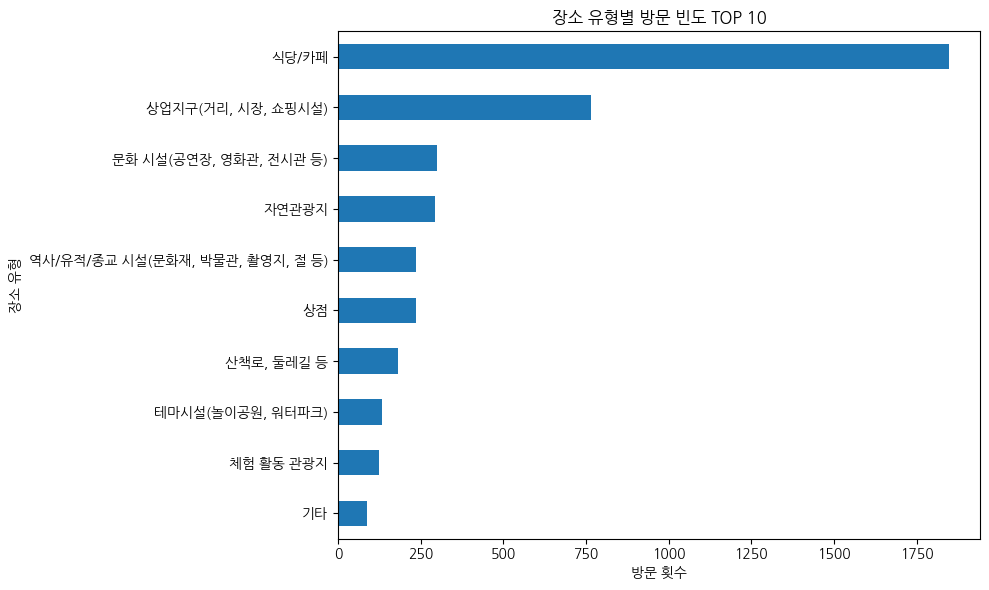

,count
VISIT_AREA_TYPE_NM,
식당/카페,1849
"상업지구(거리, 시장, 쇼핑시설)",766
"문화 시설(공연장, 영화관, 전시관 등)",300
자연관광지,295
"역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)",237
상점,235
"산책로, 둘레길 등",181
"테마시설(놀이공원, 워터파크)",133
체험 활동 관광지,124


In [14]:
type_count = clean_visit["VISIT_AREA_TYPE_NM"].value_counts().head(10)

plt.figure(figsize=(10, 6))
type_count.sort_values().plot(kind="barh")
plt.title("장소 유형별 방문 빈도 TOP 10")
plt.xlabel("방문 횟수")
plt.ylabel("장소 유형")
plt.tight_layout()
plt.show()

type_count

### 6.2. 장소 유형별 평균 만족도

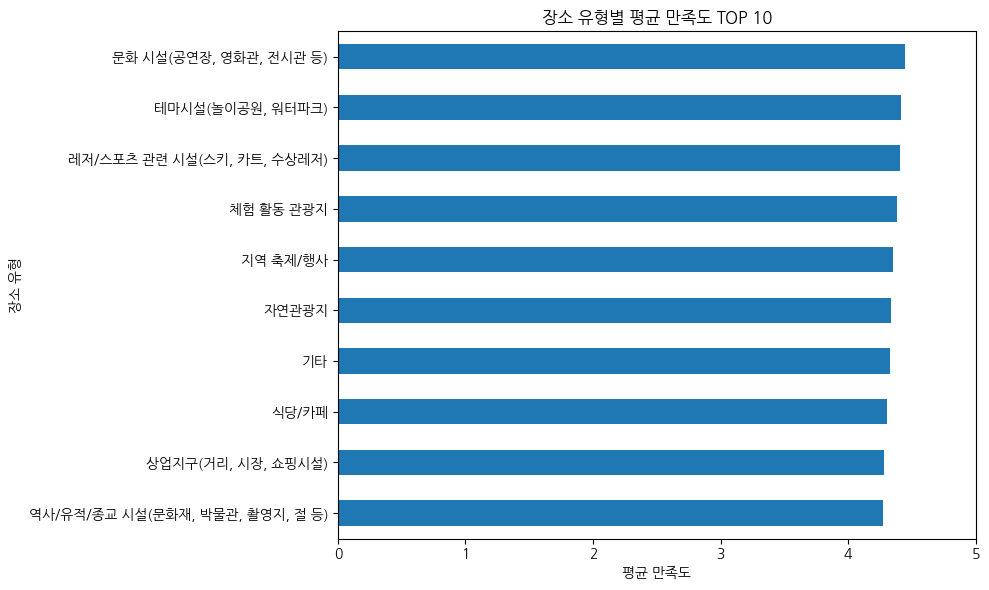

,mean,count
VISIT_AREA_TYPE_NM,,
"문화 시설(공연장, 영화관, 전시관 등)",4.443333,300
"테마시설(놀이공원, 워터파크)",4.413534,133
"레저/스포츠 관련 시설(스키, 카트, 수상레저)",4.409091,66
체험 활동 관광지,4.379032,124
지역 축제/행사,4.351852,54
자연관광지,4.332203,295
기타,4.325843,89
식당/카페,4.304489,1849
"상업지구(거리, 시장, 쇼핑시설)",4.284595,766


In [15]:
satisfaction_by_type = clean_visit.groupby("VISIT_AREA_TYPE_NM")["DGSTFN"].agg(["mean", "count"])
satisfaction_by_type = satisfaction_by_type[satisfaction_by_type["count"] >= 30]
satisfaction_by_type = satisfaction_by_type.sort_values("mean", ascending=False).head(10)

plt.figure(figsize=(10, 6))
satisfaction_by_type["mean"].sort_values().plot(kind="barh")
plt.title("장소 유형별 평균 만족도 TOP 10")
plt.xlabel("평균 만족도")
plt.ylabel("장소 유형")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

satisfaction_by_type

### 6.3. 장소 유형별 평균 체류 시간

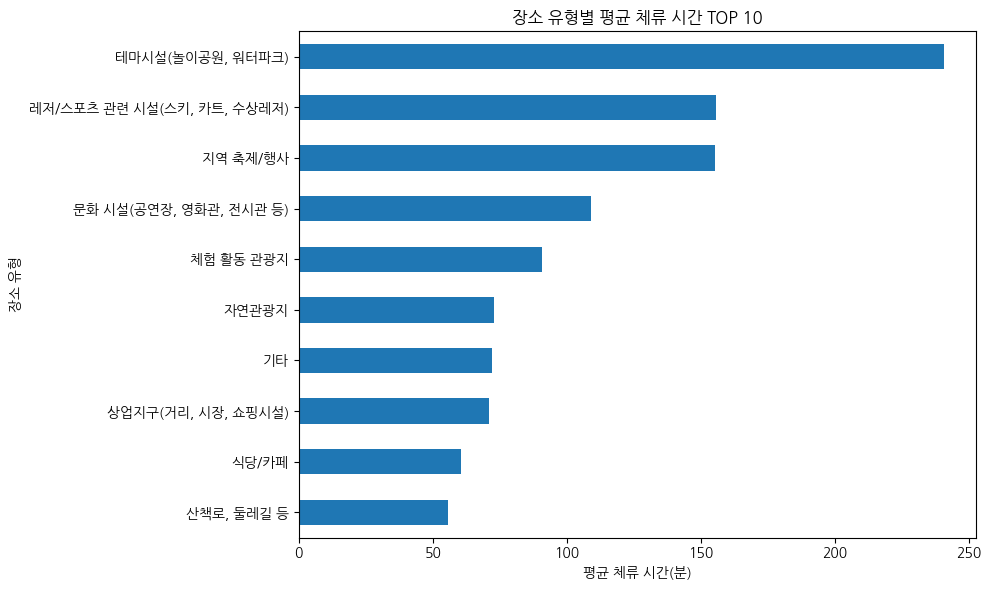

,mean,count
VISIT_AREA_TYPE_NM,,
"테마시설(놀이공원, 워터파크)",240.902256,133
"레저/스포츠 관련 시설(스키, 카트, 수상레저)",155.909091,66
지역 축제/행사,155.555556,54
"문화 시설(공연장, 영화관, 전시관 등)",109.200000,300
체험 활동 관광지,90.967742,124
자연관광지,72.915254,295
기타,72.134831,89
"상업지구(거리, 시장, 쇼핑시설)",71.122715,766
식당/카페,60.713899,1849


In [16]:
clean_visit["RESIDENCE_TIME_MIN"] = pd.to_numeric(
    clean_visit["RESIDENCE_TIME_MIN"], errors="coerce"
)

stay_by_type = clean_visit.groupby("VISIT_AREA_TYPE_NM")["RESIDENCE_TIME_MIN"].agg(["mean", "count"])
stay_by_type = stay_by_type[stay_by_type["count"] >= 30]
stay_by_type = stay_by_type.sort_values("mean", ascending=False).head(10)

plt.figure(figsize=(10, 6))
stay_by_type["mean"].sort_values().plot(kind="barh")
plt.title("장소 유형별 평균 체류 시간 TOP 10")
plt.xlabel("평균 체류 시간(분)")
plt.ylabel("장소 유형")
plt.tight_layout()
plt.show()

stay_by_type

# 7. 데이터 마이닝

## 7.1. 여행별 특징 데이터 생성

In [17]:
# 숫자형 변환
clean_visit["DGSTFN"] = pd.to_numeric(clean_visit["DGSTFN"], errors="coerce")
clean_visit["RESIDENCE_TIME_MIN"] = pd.to_numeric(clean_visit["RESIDENCE_TIME_MIN"], errors="coerce")

# 여행별 장소 유형 방문 비율
type_features = pd.crosstab(
    clean_visit["TRAVEL_ID"],
    clean_visit["VISIT_AREA_TYPE_NM"]
)

# 방문 횟수를 비율로 변환
type_ratio = type_features.div(type_features.sum(axis=1), axis=0)

# 여행별 기본 통계
basic_features = clean_visit.groupby("TRAVEL_ID").agg(
    visit_count=("VISIT_AREA_NM", "count"),
    avg_satisfaction=("DGSTFN", "mean"),
    avg_stay_time=("RESIDENCE_TIME_MIN", "mean")
)

# 최종 특징 데이터
travel_features = pd.concat([basic_features, type_ratio], axis=1)
travel_features = travel_features.fillna(0)

print("여행별 특징 데이터 크기:", travel_features.shape)
travel_features.head()

여행별 특징 데이터 크기: (790, 15)


,visit_count,avg_satisfaction,avg_stay_time,기타,"레저/스포츠 관련 시설(스키, 카트, 수상레저)","문화 시설(공연장, 영화관, 전시관 등)","산책로, 둘레길 등","상업지구(거리, 시장, 쇼핑시설)",상점,식당/카페,"역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)",자연관광지,지역 축제/행사,체험 활동 관광지,"테마시설(놀이공원, 워터파크)"
TRAVEL_ID,,,,,,,,,,,,,,,
e_e000009,8,4.875000,67.500000,0.125000,0.00,0.0,0.000000,0.125000,0.125000,0.375000,0.000000,0.000000,0.0,0.0,0.25
e_e000015,15,4.000000,68.000000,0.133333,0.00,0.2,0.066667,0.066667,0.000000,0.400000,0.000000,0.133333,0.0,0.0,0.00
e_e000021,9,4.111111,56.666667,0.222222,0.00,0.0,0.000000,0.111111,0.111111,0.444444,0.111111,0.000000,0.0,0.0,0.00
e_e000040,5,4.200000,36.000000,0.000000,0.00,0.0,0.200000,0.000000,0.000000,0.600000,0.200000,0.000000,0.0,0.0,0.00
e_e000042,4,4.250000,52.500000,0.000000,0.25,0.0,0.250000,0.000000,0.000000,0.250000,0.250000,0.000000,0.0,0.0,0.00


## 8. K-Means 군집화

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(travel_features)

# K-Means 군집화
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
travel_features["cluster"] = kmeans.fit_predict(X_scaled)

print("군집화 완료")
travel_features["cluster"].value_counts().sort_index()

군집화 완료


,count
cluster,
0,357
1,193
2,203
3,37


## 8.1. 군집별 기본 통계

In [19]:
cluster_summary = travel_features.groupby("cluster").agg(
    여행수=("visit_count", "count"),
    평균방문지수=("visit_count", "mean"),
    평균만족도=("avg_satisfaction", "mean"),
    평균체류시간=("avg_stay_time", "mean")
).round(2)

cluster_summary

,여행수,평균방문지수,평균만족도,평균체류시간
cluster,,,,
0,357,5.28,4.34,78.11
1,193,4.45,4.30,90.85
2,203,7.48,4.30,66.69
3,37,1.81,4.33,321.62


##8.2. 군집별 많이 방문한 장소 유형 확인

In [20]:
# 장소 유형 컬럼만 추출
type_cols = [col for col in travel_features.columns
             if col not in ["visit_count", "avg_satisfaction", "avg_stay_time", "cluster"]]

cluster_type_mean = travel_features.groupby("cluster")[type_cols].mean()

for cluster_id in cluster_type_mean.index:
    print(f"\n[군집 {cluster_id}] 주요 방문지 유형 TOP 5")
    print(cluster_type_mean.loc[cluster_id].sort_values(ascending=False).head(5))


[군집 0] 주요 방문지 유형 TOP 5
식당/카페                              0.550137
상업지구(거리, 시장, 쇼핑시설)                 0.104673
자연관광지                              0.102073
문화 시설(공연장, 영화관, 전시관 등)             0.075596
역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)    0.039026
Name: 0, dtype: float64

[군집 1] 주요 방문지 유형 TOP 5
상업지구(거리, 시장, 쇼핑시설)                 0.401186
식당/카페                              0.238049
산책로, 둘레길 등                         0.077608
역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)    0.075837
문화 시설(공연장, 영화관, 전시관 등)             0.061231
Name: 1, dtype: float64

[군집 2] 주요 방문지 유형 TOP 5
식당/카페                     0.390460
상점                        0.170725
상업지구(거리, 시장, 쇼핑시설)        0.130999
문화 시설(공연장, 영화관, 전시관 등)    0.064181
기타                        0.059973
Name: 2, dtype: float64

[군집 3] 주요 방문지 유형 TOP 5
테마시설(놀이공원, 워터파크)              0.608108
식당/카페                         0.123874
상업지구(거리, 시장, 쇼핑시설)            0.121622
레저/스포츠 관련 시설(스키, 카트, 수상레저)    0.040541
문화 시설(공연장, 영화관, 전시관 등)        0.040541
Name: 3, dtype: float6

## 8.3. 군집 결과 시각화

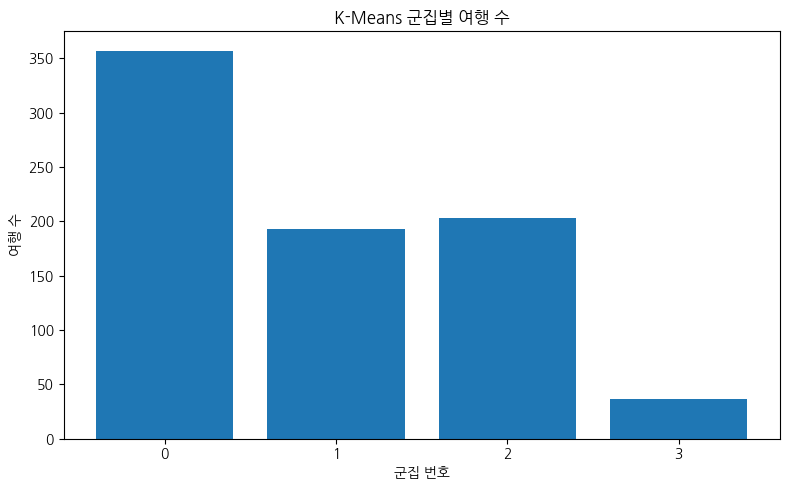

,count
cluster,
0,357
1,193
2,203
3,37


In [21]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import os

# 한글 폰트
!apt-get -qq install fonts-nanum

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rc("font", family="NanumGothic")
mpl.rcParams["axes.unicode_minus"] = False

os.makedirs("/content/graphs", exist_ok=True)

cluster_count = travel_features["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_count.index.astype(str), cluster_count.values)
plt.title("K-Means 군집별 여행 수")
plt.xlabel("군집 번호")
plt.ylabel("여행 수")
plt.tight_layout()
plt.savefig("/content/graphs/06_KMeans_군집별_여행수.png", dpi=300)
plt.show()

cluster_count

##8.4. 군집별 장소 유형 비율 그래프

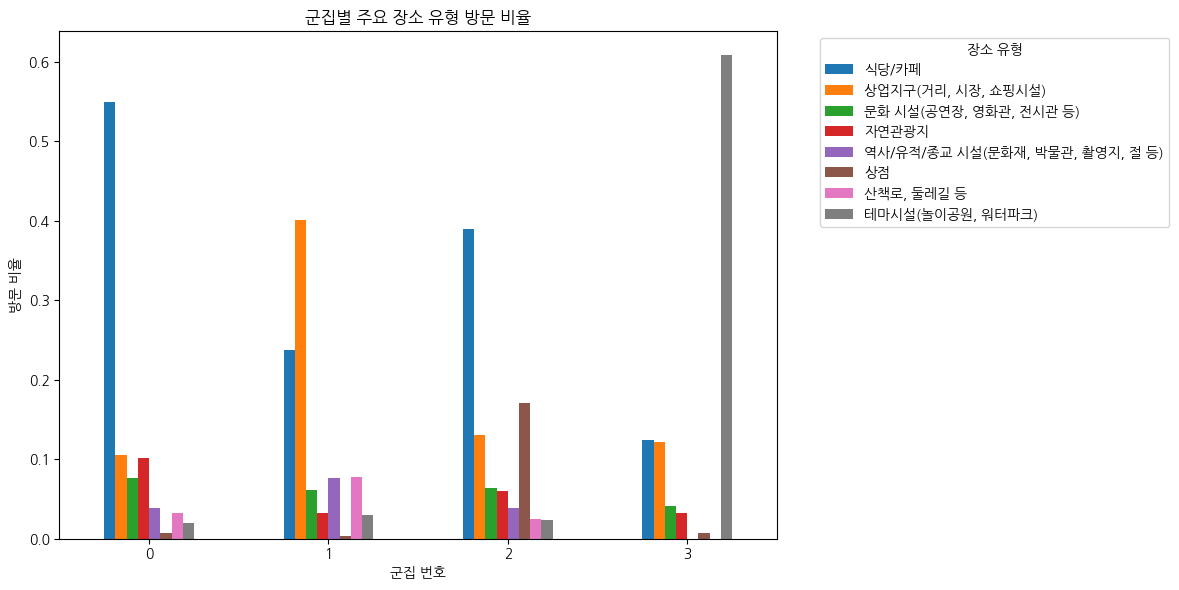

,식당/카페,"상업지구(거리, 시장, 쇼핑시설)","문화 시설(공연장, 영화관, 전시관 등)",자연관광지,"역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)",상점,"산책로, 둘레길 등","테마시설(놀이공원, 워터파크)"
cluster,,,,,,,,
0,0.550,0.105,0.076,0.102,0.039,0.007,0.032,0.020
1,0.238,0.401,0.061,0.032,0.076,0.004,0.078,0.030
2,0.390,0.131,0.064,0.060,0.039,0.171,0.025,0.023
3,0.124,0.122,0.041,0.032,0.000,0.007,0.000,0.608


In [22]:
# 전체에서 많이 등장한 장소 유형 TOP 8만 사용
top_types = clean_visit["VISIT_AREA_TYPE_NM"].value_counts().head(8).index.tolist()

cluster_top_type = travel_features.groupby("cluster")[top_types].mean().round(3)

cluster_top_type.plot(kind="bar", figsize=(12, 6))
plt.title("군집별 주요 장소 유형 방문 비율")
plt.xlabel("군집 번호")
plt.ylabel("방문 비율")
plt.xticks(rotation=0)
plt.legend(title="장소 유형", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("/content/graphs/07_군집별_장소유형_방문비율.png", dpi=300)
plt.show()

cluster_top_type

# 9. 취향 기반 추천 - Cosine Similarity

## 9.1. 장소 유형 이름 확인

In [23]:
# 장소 유형 이름 확인
print(clean_visit["VISIT_AREA_TYPE_NM"].value_counts())

VISIT_AREA_TYPE_NM
식당/카페                              1849
상업지구(거리, 시장, 쇼핑시설)                  766
문화 시설(공연장, 영화관, 전시관 등)              300
자연관광지                               295
역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)     237
상점                                  235
산책로, 둘레길 등                          181
테마시설(놀이공원, 워터파크)                    133
체험 활동 관광지                           124
기타                                   89
레저/스포츠 관련 시설(스키, 카트, 수상레저)           66
지역 축제/행사                             54
Name: count, dtype: int64


## 9.2. 유사도 계산 및 추천 코스 찾기

In [24]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# 사용자 선호 장소 유형 직접 설정
user_preference_types = [
    "식당/카페",
    "산책로, 둘레길 등",
    "문화 시설(공연장, 영화관, 전시관 등)",
    "상업지구(거리, 시장, 쇼핑시설)"
]

# 실제 feature 컬럼 중 존재하는 것만 선택
selected_types = [t for t in user_preference_types if t in type_cols]

print("선택된 사용자 선호 장소 유형:")
print(selected_types)

# 사용자 벡터 만들기
user_vector = pd.Series(0, index=type_cols)

for t in selected_types:
    user_vector[t] = 1

# 비율로 정규화
user_vector = user_vector / user_vector.sum()

# 여행별 장소 유형 비율 데이터
course_vectors = travel_features[type_cols]

# 코사인 유사도 계산
similarity_scores = cosine_similarity(
    course_vectors,
    user_vector.values.reshape(1, -1)
).flatten()

recommend_result = travel_features.copy()
recommend_result["similarity"] = similarity_scores

# 유사도 70% + 평균 만족도 30% 반영
recommend_result["final_score"] = (
    recommend_result["similarity"] * 0.7
    + recommend_result["avg_satisfaction"] / 5 * 0.3
)

# 추천 상위 5개
top_recommend = recommend_result.sort_values("final_score", ascending=False).head(5)

top_recommend[[
    "visit_count",
    "avg_satisfaction",
    "avg_stay_time",
    "cluster",
    "similarity",
    "final_score"
]]

선택된 사용자 선호 장소 유형:
['식당/카페', '산책로, 둘레길 등', '문화 시설(공연장, 영화관, 전시관 등)', '상업지구(거리, 시장, 쇼핑시설)']


,visit_count,avg_satisfaction,avg_stay_time,cluster,similarity,final_score
TRAVEL_ID,,,,,,
e_e000993,7,4.857143,68.571429,1,0.970725,0.970936
e_e004596,9,4.666667,53.333333,1,0.938315,0.936820
e_e007504,7,5.000000,68.571429,0,0.903696,0.932587
e_e002415,6,4.333333,80.000000,1,0.948683,0.924078
e_e007385,3,5.000000,80.000000,1,0.866025,0.906218


## 10. 추천 코스 상세 출력

In [25]:
best_travel_id = top_recommend.index[0]

recommended_course = clean_visit[
    clean_visit["TRAVEL_ID"] == best_travel_id
].sort_values("VISIT_ORDER")

print("추천 여행 ID:", best_travel_id)

recommended_course[[
    "VISIT_ORDER",
    "VISIT_AREA_NM",
    "VISIT_AREA_TYPE_NM",
    "DGSTFN",
    "RESIDENCE_TIME_MIN"
]]

추천 여행 ID: e_e000993


,VISIT_ORDER,VISIT_AREA_NM,VISIT_AREA_TYPE_NM,DGSTFN,RESIDENCE_TIME_MIN
2954,4,고척스카이돔,"문화 시설(공연장, 영화관, 전시관 등)",5.0,180.0
2955,5,서울아트 책 보고,"문화 시설(공연장, 영화관, 전시관 등)",5.0,30.0
2956,6,부평 칼국수,식당/카페,5.0,30.0
2958,8,부평공원,"산책로, 둘레길 등",4.0,30.0
2959,9,롯데백화점 인천점,"상업지구(거리, 시장, 쇼핑시설)",5.0,120.0
2961,11,아이파크몰 용산점,"상업지구(거리, 시장, 쇼핑시설)",5.0,60.0
2962,12,풍국면 용산 아이파크몰점,식당/카페,5.0,30.0


# 11. 거리 기반 추천

## 11.1. GPS 및 거리 기반 한계 확인
1차 추천 결과는 취향 유사도는 높았지만, 방문지 간 이동거리가 과도하게 긴 문제가 있어 거리 조건을 추가할 필요가 있었다.

### 11.1.1. TL_GPS 데이터 다운로드

In [26]:
print("TL_gps_zip.zip 파일을 업로드해주세요.")
uploaded_gps = files.upload()

TL_gps_zip.zip 파일을 업로드해주세요.


Saving TL_gps_zip.zip to TL_gps_zip.zip


### 11.1.2. GPS zip 안에서 추천 여행 ID 찾기

In [27]:
gps_zip_path = "/content/TL_gps_zip.zip"

# NOTE: best_travel_id는 뒤에서 계산되므로, 여기서는 임시로 처음 추천된 ID를 사용합니다.
target_travel_id = "e_e000993"  # 예시로 첫 번째 추천 ID를 직접 지정

with zipfile.ZipFile(gps_zip_path, "r") as z:
    gps_files = z.namelist()

print("GPS 파일 개수:", len(gps_files))

target_files = [f for f in gps_files if target_travel_id in f]

print("추천 여행 ID:", target_travel_id)
print("찾은 GPS 파일:")
print(target_files[:10])

GPS 파일 개수: 2561
추천 여행 ID: e_e000993
찾은 GPS 파일:
['TL_gps_data/tn_gps_coord_e_e000993.csv']


### 11.1.3. GPS 파일 읽기

In [28]:
with zipfile.ZipFile(gps_zip_path, "r") as z:
    with z.open(target_files[0]) as f:
        gps = pd.read_csv(f)

print("GPS 데이터 크기:", gps.shape)
print("컬럼:")
print(gps.columns)
gps.head()
# 칼럼 이름 확인이 제일 중요 - 경도/위도/시간 관련 칼럼이 있을

GPS 데이터 크기: (22645, 5)
컬럼:
Index(['MOBILE_NUM_ID', 'X_COORD', 'Y_COORD', 'DT_MIN', 'TRAVEL_ID'], dtype='object')


,MOBILE_NUM_ID,X_COORD,Y_COORD,DT_MIN,TRAVEL_ID
0,e000993_58829,127.118304,35.804914,2023-05-26 17:23,e_e000993
1,e000993_58829,127.118304,35.804914,2023-05-26 17:23,e_e000993
2,e000993_58829,127.118304,35.804914,2023-05-26 17:23,e_e000993
3,e000993_58829,127.118304,35.804914,2023-05-26 17:25,e_e000993
4,e000993_58829,127.118304,35.804914,2023-05-26 17:25,e_e000993


### 11.1.4. GPS 이동 경로 그래프 그리기

In [29]:
# GPS 좌표 숫자형 변환
gps["X_COORD"] = pd.to_numeric(gps["X_COORD"], errors="coerce")
gps["Y_COORD"] = pd.to_numeric(gps["Y_COORD"], errors="coerce")

gps_clean = gps.dropna(subset=["X_COORD", "Y_COORD"]).copy()

# 추천 방문지 좌표
course_points = recommended_course.copy()
course_points["X_COORD"] = pd.to_numeric(course_points["X_COORD"], errors="coerce")
course_points["Y_COORD"] = pd.to_numeric(course_points["Y_COORD"], errors="coerce")
course_points = course_points.dropna(subset=["X_COORD", "Y_COORD"]).copy()

# 추천 방문지 주변 범위 설정
margin = 0.15

min_x = course_points["X_COORD"].min() - margin
max_x = course_points["X_COORD"].max() + margin
min_y = course_points["Y_COORD"].min() - margin
max_y = course_points["Y_COORD"].max() + margin

gps_near_course = gps_clean[
    (gps_clean["X_COORD"] >= min_x) &
    (gps_clean["X_COORD"] <= max_x) &
    (gps_clean["Y_COORD"] >= min_y) &
    (gps_clean["Y_COORD"] <= max_y)
].copy()

print("전체 GPS 기록 수:", len(gps_clean))
print("추천 코스 주변 GPS 기록 수:", len(gps_near_course))
print("추천 방문지 수:", len(course_points))

전체 GPS 기록 수: 22645
추천 코스 주변 GPS 기록 수: 12286
추천 방문지 수: 7


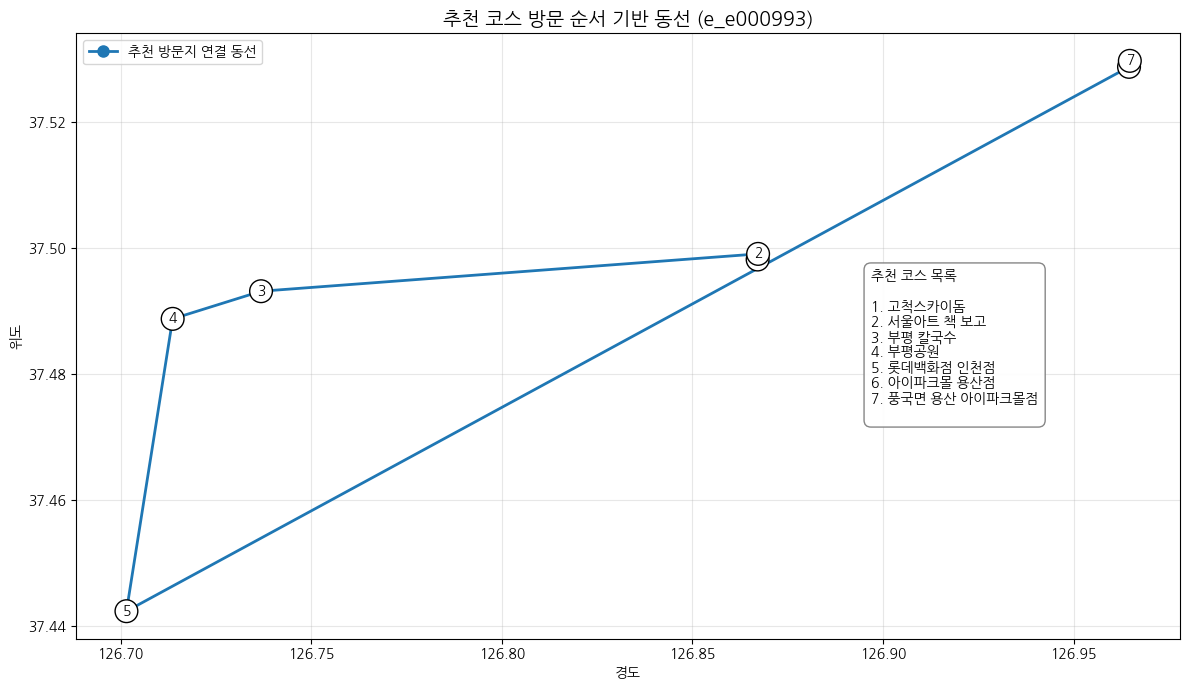

In [30]:
# 방문지 순서 정리
course_route = course_points.sort_values("VISIT_ORDER").copy().reset_index(drop=True)
course_route["추천순서"] = range(1, len(course_route) + 1)

# 그래프 생성
fig, ax = plt.subplots(figsize=(12, 7))

# 방문지 연결 동선
ax.plot(
    course_route["X_COORD"],
    course_route["Y_COORD"],
    marker="o",
    linewidth=2,
    markersize=8,
    label="추천 방문지 연결 동선"
)

# 각 방문지에 번호만 표시
for _, row in course_route.iterrows():
    ax.annotate(
        str(row["추천순서"]),
        xy=(row["X_COORD"], row["Y_COORD"]),
        xytext=(0, 0),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            boxstyle="circle,pad=0.35",
            facecolor="white",
            edgecolor="black",
            linewidth=1
        )
    )

# 오른쪽에 장소 목록 박스 만들기
course_text = "추천 코스 목록\n\n"
for _, row in course_route.iterrows():
    course_text += f"{row['추천순서']}. {row['VISIT_AREA_NM']}\n"

# 그래프 오른쪽 여백 확보
plt.subplots_adjust(right=0.70)

fig.text(
    0.73,
    0.5,
    course_text,
    fontsize=10,
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray",
        alpha=0.95
    )
)

ax.set_title(f"추천 코스 방문 순서 기반 동선 ({target_travel_id})", fontsize=14)
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("/content/graphs/10_추천코스_방문지_연결동선_수정.png", dpi=300, bbox_inches="tight")
plt.show()

## 11.2. 거리·다양성 반영 추천
1차 추천 결과는 사용자 취향과 유사했지만, 일부 코스에서 이동거리가 과도하게 길어지는 한계가 있었다.  
따라서 취향 유사도, 평균 만족도, 이동거리, 장소 유형 다양성을 함께 반영하여 최종 추천 코스를 다시 도출하였다.

## 11.2.1. 거리 정보 계산

In [49]:
from IPython.display import display

# 좌표 숫자형 변환
clean_visit["X_COORD"] = pd.to_numeric(clean_visit["X_COORD"], errors="coerce")
clean_visit["Y_COORD"] = pd.to_numeric(clean_visit["Y_COORD"], errors="coerce")

# 위경도 기반 거리 계산 함수
def haversine(lon1, lat1, lon2, lat2):
    R = 6371  # km
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 여행별 총 이동거리, 장소 간 최대 이동거리 계산
def calc_route_info(group):
    group = group.sort_values("VISIT_ORDER").dropna(subset=["X_COORD", "Y_COORD"]).copy()

    if len(group) < 2:
        return pd.Series({
            "route_distance_km": 0,
            "max_step_distance_km": 0,
            "valid_point_count": len(group)
        })

    lon = group["X_COORD"].values
    lat = group["Y_COORD"].values
    distances = haversine(lon[:-1], lat[:-1], lon[1:], lat[1:])

    return pd.Series({
        "route_distance_km": distances.sum(),
        "max_step_distance_km": distances.max(),
        "valid_point_count": len(group)
    })

route_info = clean_visit.groupby("TRAVEL_ID").apply(calc_route_info)
route_info.index.name = "TRAVEL_ID"

route_info.head()

/tmp/ipykernel_2717/3938863657.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  route_info = clean_visit.groupby("TRAVEL_ID").apply(calc_route_info)


,route_distance_km,max_step_distance_km,valid_point_count
TRAVEL_ID,,,
e_e000009,23.349736,6.726965,8.0
e_e000015,39.177932,8.676669,15.0
e_e000021,20.801065,5.397202,9.0
e_e000040,1.707428,0.688902,5.0
e_e000042,9.730061,6.360222,4.0


## 11.2.2. 취향 유사도 다시 계산

In [50]:
# 장소 유형 컬럼 정의
type_cols = [
    col for col in travel_features.columns
    if col not in ["visit_count", "avg_satisfaction", "avg_stay_time", "cluster"]
]

# 사용자 선호 장소 유형
user_preference_types = [
    "식당/카페",
    "산책로, 둘레길 등",
    "문화 시설(공연장, 영화관, 전시관 등)",
    "상업지구(거리, 시장, 쇼핑시설)"
]

selected_types = [t for t in user_preference_types if t in type_cols]

print("선택된 사용자 선호 장소 유형:")
print(selected_types)

# 사용자 선호 벡터 생성
user_vector = pd.Series(0, index=type_cols)

for t in selected_types:
    user_vector[t] = 1

user_vector = user_vector / user_vector.sum()

# 여행별 장소 유형 비율 벡터
course_vectors = travel_features[type_cols]

# 코사인 유사도 계산
similarity_scores = cosine_similarity(
    course_vectors,
    user_vector.values.reshape(1, -1)
).flatten()

recommend_final = travel_features.copy()
recommend_final["similarity"] = similarity_scores

선택된 사용자 선호 장소 유형:
['식당/카페', '산책로, 둘레길 등', '문화 시설(공연장, 영화관, 전시관 등)', '상업지구(거리, 시장, 쇼핑시설)']


## 11.2.3. 거리·다양성 정보 결합

In [51]:
# 거리 정보 결합
recommend_final = recommend_final.join(route_info, how="left")

# 장소 유형 다양성 계산
type_diversity = clean_visit.groupby("TRAVEL_ID")["VISIT_AREA_TYPE_NM"].nunique()
type_diversity.name = "type_diversity"

recommend_final = recommend_final.join(type_diversity, how="left")

# 장소 유형별 포함 여부 계산
type_count = pd.crosstab(
    clean_visit["TRAVEL_ID"],
    clean_visit["VISIT_AREA_TYPE_NM"]
)

type_count = type_count.reindex(recommend_final.index).fillna(0)

# 선호 장소 유형별 방문 횟수 추가
for col in selected_types:
    if col in type_count.columns:
        recommend_final[col + "_count"] = type_count[col]
    else:
        recommend_final[col + "_count"] = 0

recommend_final = recommend_final.fillna(0)

# 좌표가 있는 방문지 비율
recommend_final["coord_ratio"] = (
    recommend_final["valid_point_count"] / recommend_final["visit_count"]
).replace([np.inf, -np.inf], 0).fillna(0)

recommend_final[[
    "visit_count",
    "avg_satisfaction",
    "similarity",
    "route_distance_km",
    "max_step_distance_km",
    "valid_point_count",
    "coord_ratio",
    "type_diversity"
]].head()

,visit_count,avg_satisfaction,similarity,route_distance_km,max_step_distance_km,valid_point_count,coord_ratio,type_diversity
TRAVEL_ID,,,,,,,,
e_e000009,8,4.875000,0.500000,23.349736,6.726965,8.0,1.0,5
e_e000015,15,4.000000,0.741620,39.177932,8.676669,15.0,1.0,6
e_e000021,9,4.111111,0.521286,20.801065,5.397202,9.0,1.0,5
e_e000040,5,4.200000,0.603023,1.707428,0.688902,5.0,1.0,3
e_e000042,4,4.250000,0.500000,9.730061,6.360222,4.0,1.0,4


##11.2.4. 조건을 적용해 최종 후보 필터링

In [52]:
# 기본 조건
max_total_distance = 30   # 총 이동거리 30km 이하
max_step_distance = 12    # 장소 간 최대 이동거리 12km 이하

# 식당/카페 포함 여부
has_food = recommend_final["식당/카페_count"] >= 1

# 문화/산책/쇼핑 중 2개 이상 포함
main_type_cols = [
    "산책로, 둘레길 등_count",
    "문화 시설(공연장, 영화관, 전시관 등)_count",
    "상업지구(거리, 시장, 쇼핑시설)_count"
]

for col in main_type_cols:
    if col not in recommend_final.columns:
        recommend_final[col] = 0

main_type_score = recommend_final[main_type_cols].gt(0).sum(axis=1)

# 최종 후보 필터링
filtered_final = recommend_final[
    (recommend_final["visit_count"] >= 4) &
    (recommend_final["valid_point_count"] >= 3) &
    (recommend_final["coord_ratio"] >= 0.6) &
    (recommend_final["type_diversity"] >= 3) &
    (recommend_final["avg_satisfaction"] >= 4.0) &
    (recommend_final["route_distance_km"] <= max_total_distance) &
    (recommend_final["max_step_distance_km"] <= max_step_distance) &
    (has_food) &
    (main_type_score >= 2)
].copy()

print("최종 추천 후보 수:", len(filtered_final))

# 후보가 너무 적을 경우 조건 완화
if len(filtered_final) == 0:
    print("후보가 없어 거리 조건을 완화합니다.")

    max_total_distance = 40
    max_step_distance = 15

    filtered_final = recommend_final[
        (recommend_final["visit_count"] >= 4) &
        (recommend_final["valid_point_count"] >= 3) &
        (recommend_final["type_diversity"] >= 3) &
        (recommend_final["avg_satisfaction"] >= 4.0) &
        (recommend_final["route_distance_km"] <= max_total_distance) &
        (recommend_final["max_step_distance_km"] <= max_step_distance) &
        (has_food) &
        (main_type_score >= 2)
    ].copy()

print("최종 후보 수:", len(filtered_final))

최종 추천 후보 수: 105
최종 후보 수: 105


## 11.2.5. 최종 추천 점수 계산

In [53]:
# 거리 점수 계산
filtered_final["total_distance_score"] = 1 - (
    filtered_final["route_distance_km"] / max_total_distance
)

filtered_final["step_distance_score"] = 1 - (
    filtered_final["max_step_distance_km"] / max_step_distance
)

filtered_final["total_distance_score"] = filtered_final["total_distance_score"].clip(0, 1)
filtered_final["step_distance_score"] = filtered_final["step_distance_score"].clip(0, 1)

filtered_final["distance_score"] = (
    filtered_final["total_distance_score"] * 0.6 +
    filtered_final["step_distance_score"] * 0.4
)

# 다양성 점수
filtered_final["diversity_score"] = (filtered_final["type_diversity"] / 4).clip(0, 1)

# 최종 추천 점수
filtered_final["final_score"] = (
    filtered_final["similarity"] * 0.45 +
    (filtered_final["avg_satisfaction"] / 5) * 0.25 +
    filtered_final["distance_score"] * 0.20 +
    filtered_final["diversity_score"] * 0.10
)

top_recommend_final = filtered_final.sort_values(
    "final_score",
    ascending=False
).head(10)

display(top_recommend_final[[
    "visit_count",
    "valid_point_count",
    "coord_ratio",
    "type_diversity",
    "avg_satisfaction",
    "similarity",
    "route_distance_km",
    "max_step_distance_km",
    "distance_score",
    "diversity_score",
    "final_score"
]].round(3))

,visit_count,valid_point_count,coord_ratio,type_diversity,avg_satisfaction,similarity,route_distance_km,max_step_distance_km,distance_score,diversity_score,final_score
TRAVEL_ID,,,,,,,,,,,
e_e002340,7,7.0,1.000,5,5.000,0.832,3.531,1.141,0.891,1.00,0.903
e_e001510,5,4.0,0.800,4,5.000,0.756,0.498,0.269,0.981,1.00,0.886
e_e004084,6,5.0,0.833,4,4.833,0.791,1.536,0.816,0.942,1.00,0.886
e_e004970,5,5.0,1.000,4,4.000,0.945,5.365,3.163,0.787,1.00,0.883
e_e009675,9,9.0,1.000,6,4.667,0.849,4.491,2.430,0.829,1.00,0.881
e_e003279,4,4.0,1.000,4,5.000,0.750,1.169,0.514,0.959,1.00,0.879
e_e006544,7,7.0,1.000,3,5.000,0.803,1.456,0.452,0.956,0.75,0.877
e_e008606,4,4.0,1.000,3,4.750,0.816,1.199,0.435,0.962,0.75,0.872
e_e008520,5,5.0,1.000,5,4.200,0.894,5.870,2.764,0.790,1.00,0.871


## 11.2.6. 최종 추천 코스 출력

In [54]:
best_travel_id_final = top_recommend_final.index[0]

recommended_course_final = clean_visit[
    clean_visit["TRAVEL_ID"] == best_travel_id_final
].sort_values("VISIT_ORDER").copy()

recommended_course_final["추천순서"] = range(1, len(recommended_course_final) + 1)

print("거리·다양성 반영 최종 추천 여행 ID:", best_travel_id_final)

display(recommended_course_final[[
    "추천순서",
    "VISIT_AREA_NM",
    "VISIT_AREA_TYPE_NM",
    "DGSTFN",
    "RESIDENCE_TIME_MIN",
    "X_COORD",
    "Y_COORD"
]])

거리·다양성 반영 최종 추천 여행 ID: e_e002340


,추천순서,VISIT_AREA_NM,VISIT_AREA_TYPE_NM,DGSTFN,RESIDENCE_TIME_MIN,X_COORD,Y_COORD
6102,1,CGV 피카디리 1958,"문화 시설(공연장, 영화관, 전시관 등)",5.0,150.0,126.991313,37.570994
6104,2,익선동 한옥거리,"상업지구(거리, 시장, 쇼핑시설)",5.0,60.0,126.989776,37.573437
6105,3,탑골공원,"역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)",5.0,30.0,126.988345,37.571167
6106,4,도넛 정수,식당/카페,5.0,60.0,126.989914,37.574079
6107,5,모이소 한 마리 정육 식당 종로점,식당/카페,5.0,90.0,126.989871,37.569952
6109,6,청계천,"산책로, 둘레길 등",5.0,60.0,126.978647,37.569147
6108,7,이디야커피 종로 3가 점,식당/카페,5.0,60.0,126.991538,37.570104


## 11.2.7. 최종 추천 코스 거리표

In [55]:
course_dist = recommended_course_final.copy()

course_dist["X_COORD"] = pd.to_numeric(course_dist["X_COORD"], errors="coerce")
course_dist["Y_COORD"] = pd.to_numeric(course_dist["Y_COORD"], errors="coerce")

course_dist = course_dist.dropna(subset=["X_COORD", "Y_COORD"])
course_dist = course_dist.sort_values("추천순서").reset_index(drop=True)

lon = course_dist["X_COORD"].values
lat = course_dist["Y_COORD"].values

if len(course_dist) >= 2:
    step_distances = haversine(lon[:-1], lat[:-1], lon[1:], lat[1:])
else:
    step_distances = []

distance_table_final = course_dist[[
    "추천순서",
    "VISIT_AREA_NM",
    "VISIT_AREA_TYPE_NM",
    "DGSTFN",
    "RESIDENCE_TIME_MIN"
]].copy()

distance_table_final["다음 장소까지 거리(km)"] = list(np.round(step_distances, 2)) + [None]

print("총 이동거리(km):", round(np.sum(step_distances), 2))
print("장소 간 최대 이동거리(km):", round(np.max(step_distances), 2) if len(step_distances) > 0 else 0)

display(distance_table_final)

총 이동거리(km): 3.53
장소 간 최대 이동거리(km): 1.14


,추천순서,VISIT_AREA_NM,VISIT_AREA_TYPE_NM,DGSTFN,RESIDENCE_TIME_MIN,다음 장소까지 거리(km)
0,1,CGV 피카디리 1958,"문화 시설(공연장, 영화관, 전시관 등)",5.0,150.0,0.30
1,2,익선동 한옥거리,"상업지구(거리, 시장, 쇼핑시설)",5.0,60.0,0.28
2,3,탑골공원,"역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)",5.0,30.0,0.35
3,4,도넛 정수,식당/카페,5.0,60.0,0.46
4,5,모이소 한 마리 정육 식당 종로점,식당/카페,5.0,90.0,0.99
5,6,청계천,"산책로, 둘레길 등",5.0,60.0,1.14
6,7,이디야커피 종로 3가 점,식당/카페,5.0,60.0,NaN


## 11.2.8. 최종 추천 코스 시각화

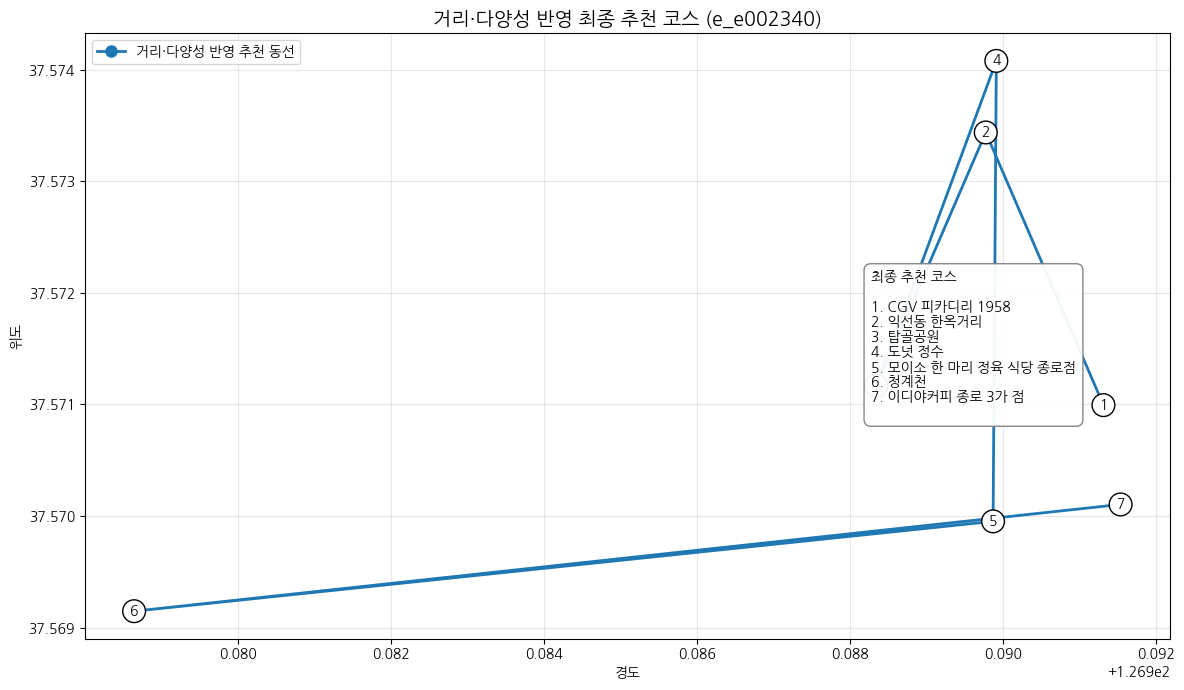

In [56]:
os.makedirs("/content/graphs", exist_ok=True)

course_route = recommended_course_final.copy()

course_route["X_COORD"] = pd.to_numeric(course_route["X_COORD"], errors="coerce")
course_route["Y_COORD"] = pd.to_numeric(course_route["Y_COORD"], errors="coerce")

course_route = course_route.dropna(subset=["X_COORD", "Y_COORD"])
course_route = course_route.sort_values("추천순서").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(
    course_route["X_COORD"],
    course_route["Y_COORD"],
    marker="o",
    linewidth=2,
    markersize=8,
    label="거리·다양성 반영 추천 동선"
)

for _, row in course_route.iterrows():
    ax.annotate(
        str(row["추천순서"]),
        xy=(row["X_COORD"], row["Y_COORD"]),
        xytext=(0, 0),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            boxstyle="circle,pad=0.35",
            facecolor="white",
            edgecolor="black",
            linewidth=1
        )
    )

course_text = "최종 추천 코스\n\n"
for _, row in course_route.iterrows():
    course_text += f"{row['추천순서']}. {row['VISIT_AREA_NM']}\n"

plt.subplots_adjust(right=0.70)

fig.text(
    0.73,
    0.5,
    course_text,
    fontsize=10,
    va="center",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray",
        alpha=0.95
    )
)

ax.set_title(
    f"거리·다양성 반영 최종 추천 코스 ({best_travel_id_final})",
    fontsize=14
)
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("/content/graphs/거리다양성반영_최종추천코스.png", dpi=300, bbox_inches="tight")
plt.show()

# 12. 추천 코스 지도 어플 연동

## 12.1. 네이버지도 길찾기 링크 생성
국내에서는 구글맵으로 도보, 자동차 길찾기에 오류가 나는 경우가 많아 네이버맵을 사용함.  
링크를 통해 직접 추천된 코스의 이동방법을 쉽게 찾을 수 있음

In [60]:
from urllib.parse import quote
import pandas as pd
from IPython.display import display, HTML

# 최종 추천 코스 데이터프레임 선택
course_map = recommended_course_final.copy()

course_map["X_COORD"] = pd.to_numeric(course_map["X_COORD"], errors="coerce")
course_map["Y_COORD"] = pd.to_numeric(course_map["Y_COORD"], errors="coerce")

course_map = course_map.dropna(subset=["X_COORD", "Y_COORD"])
course_map = course_map.sort_values("추천순서").reset_index(drop=True)

naver_web_links = []

for i in range(len(course_map) - 1):
    start = course_map.loc[i]
    end = course_map.loc[i + 1]

    start_name = str(start["VISIT_AREA_NM"])
    end_name = str(end["VISIT_AREA_NM"])

    # X_COORD = 경도, Y_COORD = 위도
    sx = start["X_COORD"]
    sy = start["Y_COORD"]
    ex = end["X_COORD"]
    ey = end["Y_COORD"]

    # 네이버지도 웹 길찾기 URL
    # PC에서도 열리는 모바일 웹 기반 URL
    url = (
        "https://m.map.naver.com/route.nhn"
        f"?menu=route"
        f"&sname={quote(start_name)}"
        f"&sx={sx}"
        f"&sy={sy}"
        f"&ename={quote(end_name)}"
        f"&ex={ex}"
        f"&ey={ey}"
        f"&pathType=0"
        f"&showMap=true"
    )

    naver_web_links.append({
        "구간": f"{i+1}구간",
        "출발지": start_name,
        "도착지": end_name,
        "네이버지도 웹 URL": url
    })

naver_web_df = pd.DataFrame(naver_web_links)
naver_web_df

,구간,출발지,도착지,네이버지도 웹 URL
0,1구간,CGV 피카디리 1958,익선동 한옥거리,https://m.map.naver.com/route.nhn?menu=route&s...
1,2구간,익선동 한옥거리,탑골공원,https://m.map.naver.com/route.nhn?menu=route&s...
2,3구간,탑골공원,도넛 정수,https://m.map.naver.com/route.nhn?menu=route&s...
3,4구간,도넛 정수,모이소 한 마리 정육 식당 종로점,https://m.map.naver.com/route.nhn?menu=route&s...
4,5구간,모이소 한 마리 정육 식당 종로점,청계천,https://m.map.naver.com/route.nhn?menu=route&s...
5,6구간,청계천,이디야커피 종로 3가 점,https://m.map.naver.com/route.nhn?menu=route&s...


In [61]:
html = """
<h3>구간별 네이버지도 웹 길찾기 링크</h3>
<p>아래 링크를 클릭하면 PC 웹브라우저에서 네이버지도 길찾기 화면이 열립니다.</p>
"""

for _, row in naver_web_df.iterrows():
    html += f"""
    <div style="margin-bottom:14px; padding:10px; border:1px solid #ddd; border-radius:8px;">
        <b>{row['구간']}</b><br>
        {row['출발지']} → {row['도착지']}<br>
        <a href="{row['네이버지도 웹 URL']}" target="_blank">네이버지도 웹에서 경로 보기</a>
    </div>
    """

display(HTML(html))

# 13. Validation

## 13.1. Validation CSV 불러오기

In [62]:
print("VL_csv_zip.zip 파일을 업로드해주세요.")
uploaded_vl_csv = files.upload()

VL_csv_zip.zip 파일을 업로드해주세요.


Saving VL_csv_zip.zip to VL_csv_zip.zip


In [65]:
# VL_csv.zip 압축 풀기
vl_zip_path = "/content/VL_csv_zip.zip"
vl_extract_path = "/content/VL_csv"

if os.path.exists(vl_zip_path):
    with zipfile.ZipFile(vl_zip_path, "r") as zip_ref:
        zip_ref.extractall(vl_extract_path)

print("Validation 압축 해제 완료")

# 파일 찾기 함수
def find_vl_file(keyword, exclude_keywords=[]):
    files = glob.glob("/content/VL_csv/**/*.csv", recursive=True)
    matched = []

    for f in files:
        name = os.path.basename(f)
        if keyword in name and all(ex not in name for ex in exclude_keywords):
            matched.append(f)

    if len(matched) == 0:
        raise FileNotFoundError(f"{keyword} 파일을 찾을 수 없습니다.")

    return matched[0]

def read_csv_auto(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except:
        return pd.read_csv(path, encoding="cp949")

vl_visit = read_csv_auto(find_vl_file("방문지정보"))
vl_travel = read_csv_auto(find_vl_file("여행", exclude_keywords=["여행객"]))
vl_traveller = read_csv_auto(find_vl_file("여행객"))
vl_companion = read_csv_auto(find_vl_file("동반자정보"))
vl_codeb = read_csv_auto(find_vl_file("코드B"))

print("Validation 방문지정보:", vl_visit.shape)
print("Validation 여행:", vl_travel.shape)
print("Validation 여행객:", vl_traveller.shape)
print("Validation 동반자정보:", vl_companion.shape)
print("Validation 코드B:", vl_codeb.shape)

Validation 압축 해제 완료
Validation 방문지정보: (2770, 23)
Validation 여행: (320, 10)
Validation 여행객: (320, 36)
Validation 동반자정보: (440, 6)
Validation 코드B: (238, 10)


## 13.2. Training과 같은 방식으로 전처리

In [66]:
# 방문지 유형 코드명 붙이기
vis_code_vl = vl_codeb[vl_codeb["cd_a"] == "VIS"][["cd_b", "cd_nm"]].copy()
vis_code_vl["cd_b"] = pd.to_numeric(vis_code_vl["cd_b"], errors="coerce")

vl_visit["VISIT_AREA_TYPE_CD"] = pd.to_numeric(
    vl_visit["VISIT_AREA_TYPE_CD"], errors="coerce"
)

vl_visit = vl_visit.merge(
    vis_code_vl,
    left_on="VISIT_AREA_TYPE_CD",
    right_on="cd_b",
    how="left"
)

vl_visit = vl_visit.rename(columns={"cd_nm": "VISIT_AREA_TYPE_NM"})
vl_visit = vl_visit.drop(columns=["cd_b"])

# 2인 동행 여행자 추출
vl_traveller["TRAVEL_COMPANIONS_NUM"] = pd.to_numeric(
    vl_traveller["TRAVEL_COMPANIONS_NUM"], errors="coerce"
)

vl_two_person_traveller = vl_traveller[
    vl_traveller["TRAVEL_COMPANIONS_NUM"] == 1
]

vl_two_person_travel = vl_travel[
    vl_travel["TRAVELER_ID"].isin(vl_two_person_traveller["TRAVELER_ID"])
]

vl_two_person_ids = vl_two_person_travel["TRAVEL_ID"].unique()

# 친구/연인 여행 추출
vl_companion["REL_CD"] = pd.to_numeric(vl_companion["REL_CD"], errors="coerce")

vl_friend_lover = vl_companion[vl_companion["REL_CD"].isin([7, 8])]
vl_friend_lover_ids = vl_friend_lover["TRAVEL_ID"].unique()

vl_target_ids = list(set(vl_two_person_ids) & set(vl_friend_lover_ids))

# 분석 대상 방문지 추출
vl_raw_target_visit = vl_visit[vl_visit["TRAVEL_ID"].isin(vl_target_ids)].copy()

# 집, 숙소, 사무실, 터미널 등 제거
remove_types = [21, 22, 23, 24, 9]

vl_clean_visit = vl_raw_target_visit[
    ~vl_raw_target_visit["VISIT_AREA_TYPE_CD"].isin(remove_types)
].copy()

# 만족도 결측치 제거
vl_clean_visit = vl_clean_visit.dropna(subset=["DGSTFN", "VISIT_AREA_TYPE_NM"])

vl_clean_visit["DGSTFN"] = pd.to_numeric(vl_clean_visit["DGSTFN"], errors="coerce")
vl_clean_visit["RESIDENCE_TIME_MIN"] = pd.to_numeric(
    vl_clean_visit["RESIDENCE_TIME_MIN"], errors="coerce"
)

vl_clean_visit = vl_clean_visit.sort_values(["TRAVEL_ID", "VISIT_ORDER"])

print("Validation 전체 여행 수:", vl_travel["TRAVEL_ID"].nunique())
print("Validation 2인 여행 수:", len(vl_two_person_ids))
print("Validation 2인 친구/연인 여행 수:", len(vl_target_ids))
print("Validation 전처리 전 방문지 수:", len(vl_raw_target_visit))
print("Validation 전처리 후 방문지 수:", len(vl_clean_visit))

Validation 전체 여행 수: 320
Validation 2인 여행 수: 167
Validation 2인 친구/연인 여행 수: 111
Validation 전처리 전 방문지 수: 931
Validation 전처리 후 방문지 수: 588


## 13.3. Validation 데이터에 K-Means 군집 적용

In [67]:
print("중복 컬럼 목록:")
print(vl_clean_visit.columns[vl_clean_visit.columns.duplicated()].tolist())

print(type(vl_clean_visit["TRAVEL_ID"]))
print(type(vl_clean_visit["VISIT_AREA_TYPE_NM"]))

중복 컬럼 목록:
[]
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [68]:
# 중복 컬럼 제거
vl_clean_visit = vl_clean_visit.loc[:, ~vl_clean_visit.columns.duplicated()].copy()

# 필요한 컬럼을 문자열/숫자형으로 정리
vl_clean_visit["TRAVEL_ID"] = vl_clean_visit["TRAVEL_ID"].astype(str)
vl_clean_visit["VISIT_AREA_TYPE_NM"] = vl_clean_visit["VISIT_AREA_TYPE_NM"].astype(str)
vl_clean_visit["DGSTFN"] = pd.to_numeric(vl_clean_visit["DGSTFN"], errors="coerce")
vl_clean_visit["RESIDENCE_TIME_MIN"] = pd.to_numeric(
    vl_clean_visit["RESIDENCE_TIME_MIN"], errors="coerce"
)

print("정리 후 중복 컬럼:")
print(vl_clean_visit.columns[vl_clean_visit.columns.duplicated()].tolist())

print("Validation 전처리 데이터 크기:", vl_clean_visit.shape)

정리 후 중복 컬럼:
[]
Validation 전처리 데이터 크기: (588, 24)


In [69]:
# Validation 여행별 장소 유형 방문 횟수
vl_type_features = pd.crosstab(
    vl_clean_visit["TRAVEL_ID"],
    vl_clean_visit["VISIT_AREA_TYPE_NM"]
)

# 방문 횟수를 비율로 변환
vl_type_ratio = vl_type_features.div(vl_type_features.sum(axis=1), axis=0)

# Validation 여행별 기본 통계
vl_basic_features = vl_clean_visit.groupby("TRAVEL_ID").agg(
    visit_count=("VISIT_AREA_NM", "count"),
    avg_satisfaction=("DGSTFN", "mean"),
    avg_stay_time=("RESIDENCE_TIME_MIN", "mean")
)

# Validation 특징 데이터 생성
vl_features = pd.concat([vl_basic_features, vl_type_ratio], axis=1)
vl_features = vl_features.fillna(0)

# Training에서 사용한 feature 컬럼과 동일하게 맞추기
train_feature_cols = [
    col for col in travel_features.columns
    if col not in ["cluster"]
]

vl_features = vl_features.reindex(columns=train_feature_cols, fill_value=0)

# Training에서 학습한 scaler, kmeans 그대로 적용
vl_scaled = scaler.transform(vl_features)

vl_features["cluster"] = kmeans.predict(vl_scaled)

print("Validation 특징 데이터 크기:", vl_features.shape)
print("Validation 군집 분포:")
print(vl_features["cluster"].value_counts().sort_index())

vl_features.head()

Validation 특징 데이터 크기: (111, 16)
Validation 군집 분포:
cluster
0    46
1    27
2    36
3     2
Name: count, dtype: int64


,visit_count,avg_satisfaction,avg_stay_time,기타,"레저/스포츠 관련 시설(스키, 카트, 수상레저)","문화 시설(공연장, 영화관, 전시관 등)","산책로, 둘레길 등","상업지구(거리, 시장, 쇼핑시설)",상점,식당/카페,"역사/유적/종교 시설(문화재, 박물관, 촬영지, 절 등)",자연관광지,지역 축제/행사,체험 활동 관광지,"테마시설(놀이공원, 워터파크)",cluster
TRAVEL_ID,,,,,,,,,,,,,,,,
e_e000471,6,4.666667,55.000000,0.0,0.0,0.166667,0.166667,0.000000,0.000000,0.666667,0.0,0.000,0.0,0.00,0.0,0
e_e000568,8,4.250000,60.000000,0.0,0.0,0.000000,0.000000,0.375000,0.000000,0.250000,0.0,0.125,0.0,0.25,0.0,1
e_e000589,4,5.000000,82.500000,0.0,0.0,0.500000,0.000000,0.000000,0.000000,0.500000,0.0,0.000,0.0,0.00,0.0,0
e_e000614,7,4.285714,55.714286,0.0,0.0,0.000000,0.000000,0.428571,0.142857,0.428571,0.0,0.000,0.0,0.00,0.0,2
e_e000665,5,5.000000,54.000000,0.0,0.0,0.000000,0.200000,0.400000,0.000000,0.200000,0.0,0.000,0.2,0.00,0.0,1


## 13.4. Training과 Validation 군집 분포 비교 그래프

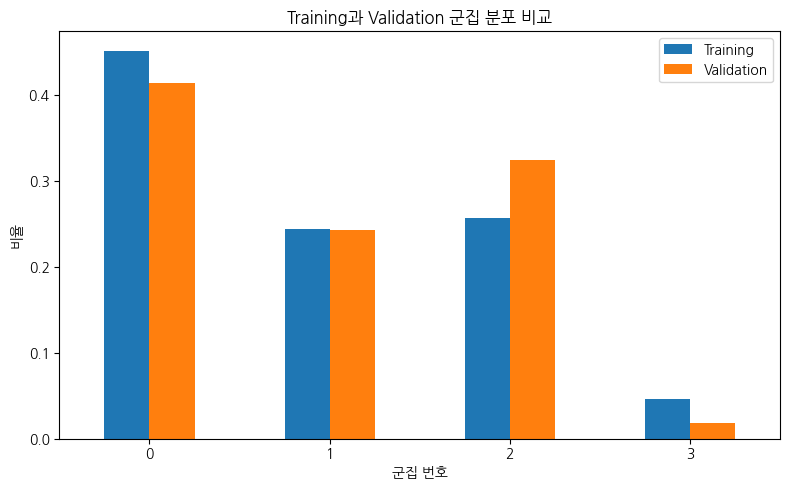

,Training,Validation
cluster,,
0,0.451899,0.414414
1,0.244304,0.243243
2,0.256962,0.324324
3,0.046835,0.018018


In [70]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import os

!apt-get -qq install fonts-nanum

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rc("font", family="NanumGothic")
mpl.rcParams["axes.unicode_minus"] = False

os.makedirs("/content/graphs", exist_ok=True)

train_cluster_ratio = travel_features["cluster"].value_counts(normalize=True).sort_index()
valid_cluster_ratio = vl_features["cluster"].value_counts(normalize=True).sort_index()

cluster_compare = pd.DataFrame({
    "Training": train_cluster_ratio,
    "Validation": valid_cluster_ratio
}).fillna(0)

cluster_compare.plot(kind="bar", figsize=(8, 5))
plt.title("Training과 Validation 군집 분포 비교")
plt.xlabel("군집 번호")
plt.ylabel("비율")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/graphs/validation_군집분포비교.png", dpi=300)
plt.show()

cluster_compare

## 13.5. Validation 데이터로 최종 추천 테스트

In [72]:
# 사용자 선호 장소 유형
user_preference_types = [
    "식당/카페",
    "산책로, 둘레길 등",
    "문화 시설(공연장, 영화관, 전시관 등)",
    "상업지구(거리, 시장, 쇼핑시설)"
]

type_cols_valid = [col for col in vl_features.columns if col not in [
    "visit_count", "avg_satisfaction", "avg_stay_time", "cluster"
]]

# Training에서 쓰던 type_cols 기준으로 맞추는 것이 좋음
type_cols_valid = type_cols

vl_course_vectors = vl_features.reindex(columns=type_cols_valid, fill_value=0)

user_vector = pd.Series(0, index=type_cols_valid)

for t in user_preference_types:
    if t in user_vector.index:
        user_vector[t] = 1

user_vector = user_vector / user_vector.sum()

vl_similarity_scores = cosine_similarity(
    vl_course_vectors,
    user_vector.values.reshape(1, -1)
).flatten()

vl_recommend = vl_features.copy()
vl_recommend["similarity"] = vl_similarity_scores

## 13.6. Validation 추천 코스 거리 계산

In [74]:
vl_clean_visit["X_COORD"] = pd.to_numeric(vl_clean_visit["X_COORD"], errors="coerce")
vl_clean_visit["Y_COORD"] = pd.to_numeric(vl_clean_visit["Y_COORD"], errors="coerce")

def haversine(lon1, lat1, lon2, lat2):
    R = 6371
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def calc_route_info(group):
    group = group.sort_values("VISIT_ORDER").dropna(subset=["X_COORD", "Y_COORD"]).copy()

    if len(group) < 2:
        return pd.Series({
            "route_distance_km": np.nan,
            "max_step_distance_km": np.nan,
            "valid_point_count": len(group)
        })

    lon = group["X_COORD"].values
    lat = group["Y_COORD"].values

    distances = haversine(lon[:-1], lat[:-1], lon[1:], lat[1:])

    return pd.Series({
        "route_distance_km": distances.sum(),
        "max_step_distance_km": distances.max(),
        "valid_point_count": len(group)
    })

vl_route_info = vl_clean_visit.groupby("TRAVEL_ID").apply(calc_route_info)

vl_type_diversity = vl_clean_visit.groupby("TRAVEL_ID")["VISIT_AREA_TYPE_NM"].nunique()
vl_type_diversity.name = "type_diversity"

vl_recommend = vl_recommend.join(vl_route_info, how="left")
vl_recommend = vl_recommend.join(vl_type_diversity, how="left")

vl_recommend = vl_recommend.fillna(0)

/tmp/ipykernel_2717/2445643216.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vl_route_info = vl_clean_visit.groupby("TRAVEL_ID").apply(calc_route_info)


## 13.7. Validation 최종 추천 결과 뽑기

In [75]:
# 조건 설정
max_total_distance = 30
max_step_distance = 12

vl_filtered = vl_recommend[
    (vl_recommend["visit_count"] >= 4) &
    (vl_recommend["type_diversity"] >= 3) &
    (vl_recommend["avg_satisfaction"] >= 4.0) &
    (vl_recommend["route_distance_km"] <= max_total_distance) &
    (vl_recommend["max_step_distance_km"] <= max_step_distance)
].copy()

print("Validation 추천 후보 수:", len(vl_filtered))

vl_filtered["distance_score"] = 1 - (vl_filtered["route_distance_km"] / max_total_distance)
vl_filtered["distance_score"] = vl_filtered["distance_score"].clip(0, 1)

vl_filtered["diversity_score"] = vl_filtered["type_diversity"] / vl_filtered["type_diversity"].max()

vl_filtered["final_score"] = (
    vl_filtered["similarity"] * 0.45 +
    (vl_filtered["avg_satisfaction"] / 5) * 0.25 +
    vl_filtered["distance_score"] * 0.20 +
    vl_filtered["diversity_score"] * 0.10
)

vl_top_recommend = vl_filtered.sort_values("final_score", ascending=False).head(5)

vl_top_recommend[[
    "visit_count",
    "type_diversity",
    "avg_satisfaction",
    "similarity",
    "route_distance_km",
    "max_step_distance_km",
    "distance_score",
    "final_score"
]].round(3)

Validation 추천 후보 수: 32


,visit_count,type_diversity,avg_satisfaction,similarity,route_distance_km,max_step_distance_km,distance_score,final_score
TRAVEL_ID,,,,,,,,
e_e010224,8,4,4.625,0.943,3.158,2.823,0.895,0.901
e_e007250,10,5,4.500,0.816,3.744,0.965,0.875,0.851
e_e010470,7,3,4.714,0.803,0.606,0.252,0.980,0.843
e_e007747,6,3,4.667,0.802,2.721,2.595,0.909,0.826
e_e010748,11,3,4.455,0.820,4.488,1.097,0.850,0.812


## 13.8. Validation 추천 코스 상세 출력

In [76]:
vl_best_id = vl_top_recommend.index[0]

vl_recommended_course = vl_clean_visit[
    vl_clean_visit["TRAVEL_ID"] == vl_best_id
].sort_values("VISIT_ORDER").copy()

vl_recommended_course["추천순서"] = range(1, len(vl_recommended_course) + 1)

print("Validation 최종 추천 여행 ID:", vl_best_id)

vl_recommended_course[[
    "추천순서",
    "VISIT_AREA_NM",
    "VISIT_AREA_TYPE_NM",
    "DGSTFN",
    "RESIDENCE_TIME_MIN",
    "X_COORD",
    "Y_COORD"
]]

Validation 최종 추천 여행 ID: e_e010224


,추천순서,VISIT_AREA_NM,VISIT_AREA_TYPE_NM,DGSTFN,RESIDENCE_TIME_MIN,X_COORD,Y_COORD
2500,1,깨비 옥 트리플 스트리트,식당/카페,5.0,30.0,NaN,NaN
2501,2,트리플 스트리트,"상업지구(거리, 시장, 쇼핑시설)",4.0,30.0,126.660997,37.379995
2502,3,현대 프리미엄 아울렛 송도점,"상업지구(거리, 시장, 쇼핑시설)",5.0,60.0,126.657905,37.381738
2503,4,돌핀 커피,식당/카페,5.0,90.0,NaN,NaN
2504,5,센트럴파크 트라이볼,"문화 시설(공연장, 영화관, 전시관 등)",4.0,30.0,NaN,NaN
2505,6,G 타워 전망대,"문화 시설(공연장, 영화관, 전시관 등)",5.0,60.0,NaN,NaN
2506,7,송도시티,식당/카페,4.0,60.0,NaN,NaN
2507,8,소찬공원,"산책로, 둘레길 등",5.0,30.0,126.628210,37.372360


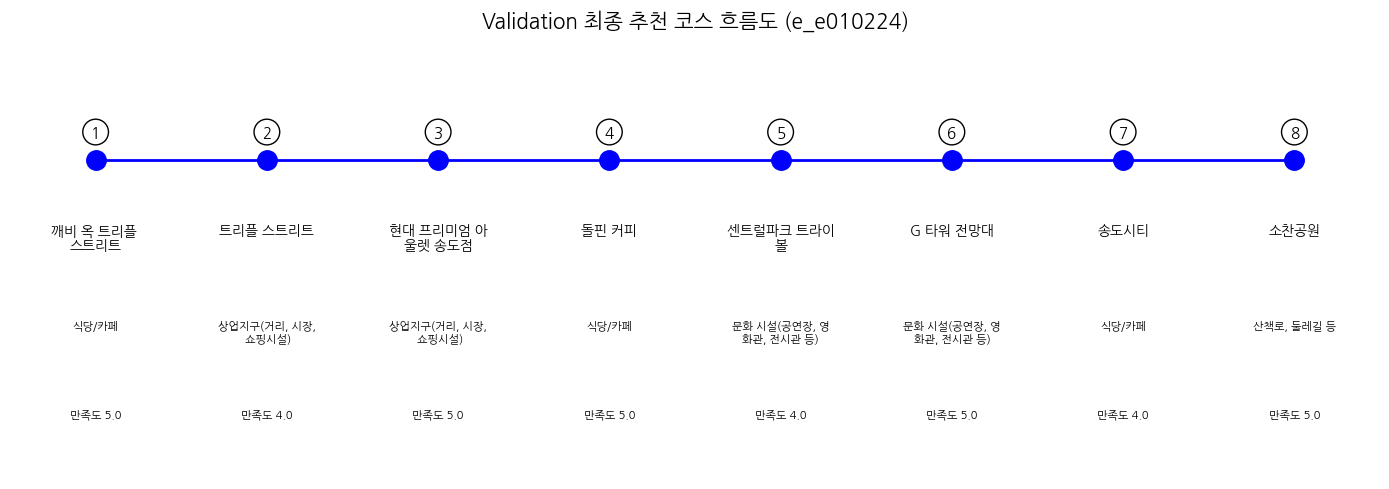

In [77]:
os.makedirs("/content/graphs", exist_ok=True)

# Validation 추천 코스 데이터
course_flow = vl_recommended_course.copy()
course_flow = course_flow.sort_values("추천순서").reset_index(drop=True)

# 장소명 줄바꿈 처리 함수
def wrap_text(text, max_len=9):
    text = str(text)
    if len(text) <= max_len:
        return text
    return "\n".join([text[i:i+max_len] for i in range(0, len(text), max_len)])

course_flow["장소표시"] = course_flow["VISIT_AREA_NM"].apply(lambda x: wrap_text(x, 9))
course_flow["유형표시"] = course_flow["VISIT_AREA_TYPE_NM"].apply(lambda x: wrap_text(x, 12))

fig, ax = plt.subplots(figsize=(14, 5))

x = range(len(course_flow))
y = [1] * len(course_flow)

# 선 연결
ax.plot(
    x,
    y,
    linewidth=2,
    marker="o",
    markersize=14,
    color='blue' # 색상 추가
)

# 번호와 장소명 표시
for i, row in course_flow.iterrows():
    ax.text(
        i,
        1.08,
        str(row["추천순서"]),
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        bbox=dict(
            boxstyle="circle,pad=0.35",
            facecolor="white",
            edgecolor="black",
            linewidth=1
        )
    )

    ax.text(
        i,
        0.82,
        row["장소표시"],
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        i,
        0.55,
        row["유형표시"],
        ha="center",
        va="top",
        fontsize=8
    )

    ax.text(
        i,
        0.30,
        f"만족도 {row['DGSTFN']}",
        ha="center",
        va="top",
        fontsize=8
    )

ax.set_title(f"Validation 최종 추천 코스 흐름도 ({vl_best_id})", fontsize=15, pad=20)
ax.set_xlim(-0.5, len(course_flow) - 0.5)
ax.set_ylim(0.1, 1.3)
ax.axis("off")

plt.tight_layout()
plt.savefig("/content/graphs/validation_최종추천코스_흐름도.png", dpi=300, bbox_inches="tight")
plt.show()